In [5]:
import sys
sys.path.append('..')
from src.order_book import OrderBook, Side
from src.market_maker import MarketMaker
from src.simulator import Simulator

import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

print("Libraries loaded successfully")

Libraries loaded successfully


In [6]:
def get_btc_trades_extended(n_batches=5):
    url = "https://api.exchange.coinbase.com/products/BTC-USD/trades"
    all_trades = []

    params = {"limit": 1000}
    for _ in range(n_batches):
        response = requests.get(url, params=params)
        batch = response.json()
        if not batch:
            break
        all_trades.extend(batch)
        oldest_id = min(t["trade_id"] for t in batch)
        params = {"limit": 1000, "after": oldest_id}

    df = pd.DataFrame(all_trades)
    df["price"] = pd.to_numeric(df["price"])
    df["size"] = pd.to_numeric(df["size"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.drop_duplicates(subset="trade_id")
    df = df.sort_values("time").reset_index(drop=True)
    df = df.set_index("time")
    return df

In [7]:
trades = get_btc_trades_extended()
print(f"Got {len(trades)} trades")

print(trades.dtypes)
trades.head()

Got 5000 trades
trade_id      int64
side         object
size        float64
price       float64
dtype: object


,trade_id,side,size,price
time,,,,
2026-05-18 22:14:18.474419+00:00,1020743691,buy,2.000000e-08,77098.39
2026-05-18 22:14:18.613891+00:00,1020743692,sell,6.485300e-04,77098.40
2026-05-18 22:14:18.865133+00:00,1020743693,buy,1.000000e-08,77098.39
2026-05-18 22:14:19.085258+00:00,1020743694,buy,6.000000e-08,77098.39
2026-05-18 22:14:19.214640+00:00,1020743695,buy,4.000000e-08,77098.39


In [8]:
book = OrderBook()
mm = MarketMaker(starting_wealth=100000, order_book=book)
sim = Simulator(mm=mm, book=book, df=trades, window=20)

mm.start_session()
sim.run()

TypeError: bad operand type for abs(): 'method'

In [ ]:
print(f"Total buy trades: {len(trades[trades['side'] == 'buy'])}")
print(f"Total sell trades: {len(trades[trades['side'] == 'sell'])}")
print(f"Starting price: {trades['price'].iloc[0]}")
print(f"Ending price: {trades['price'].iloc[-1]}")
print(f"Price change: {trades['price'].iloc[-1] - trades['price'].iloc[0]:.2f}")

Total buy trades: 2876
Total sell trades: 2124
Starting price: 76982.56
Ending price: 77035.4
Price change: 52.84


In [ ]:
results = sim.get_results()
results.tail(15)

,Mid_Price,Reservation_Price,Bid,Ask,Position,PnL,Spread
Time,,,,,,,
4985,77035.4035,77035.4035,77034.758804,77036.048196,0.183899,10.091877,1.289392
4986,77035.4040,77035.4040,77034.759304,77036.048696,0.183899,10.091969,1.289392
4987,77035.4040,77035.4040,77034.759304,77036.048696,0.183899,10.091969,1.289392
4988,77035.4035,77035.4035,77034.758804,77036.048196,0.183899,10.091877,1.289392
4989,77035.4035,77035.4035,77034.758804,77036.048196,0.183899,10.091877,1.289392
4990,77035.4030,77035.4030,77034.758304,77036.047696,0.183899,10.091785,1.289392
4991,77035.4030,77035.4030,77034.758304,77036.047696,0.183899,10.091785,1.289392
4992,77035.4035,77035.4035,77034.758804,77036.048196,0.183899,10.091877,1.289392
4993,77035.4035,77035.4035,77034.758804,77036.048196,0.183899,10.091877,1.289392


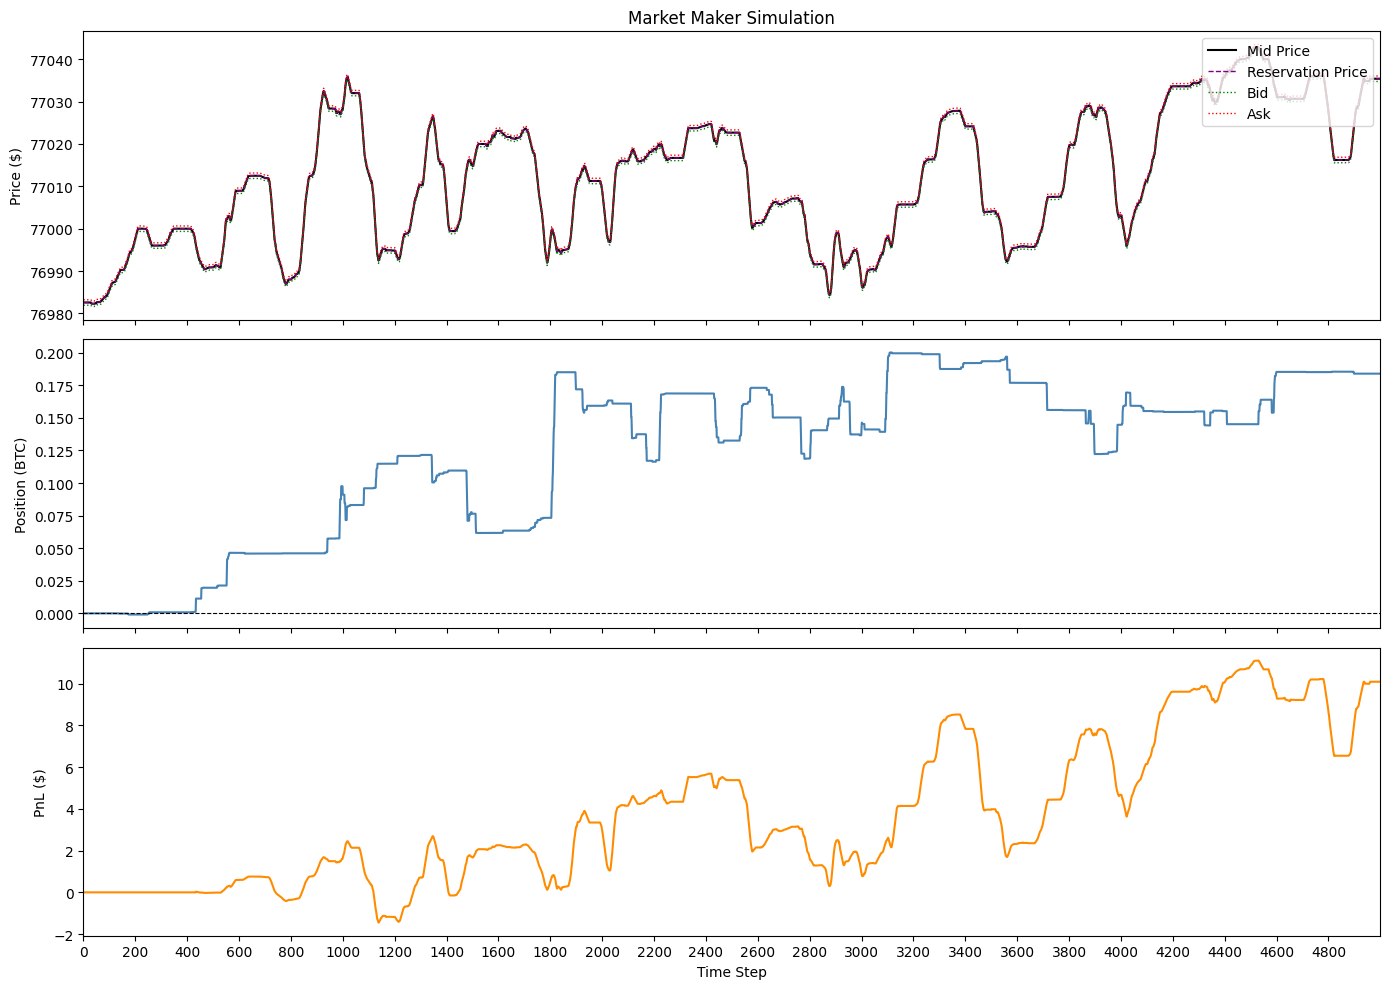

In [ ]:
from matplotlib.ticker import MultipleLocator

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax1.plot(results.index, results['Mid_Price'], label='Mid Price', color='black', linewidth=1.5)
ax1.plot(results.index, results['Reservation_Price'], label='Reservation Price', color='purple', linewidth=1, linestyle='--')
ax1.plot(results.index, results['Bid'], label='Bid', color='green', linewidth=1, linestyle=':')
ax1.plot(results.index, results['Ask'], label='Ask', color='red', linewidth=1, linestyle=':')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper right')
ax1.set_title('Market Maker Simulation')
ax1.set_xlim(results.index[0], results.index[-1])

ax2.plot(results.index, results['Position'], color='steelblue', linewidth=1.5)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Position (BTC)')

ax3.plot(results.index, results['PnL'], color='darkorange', linewidth=1.5)
ax3.set_ylabel('PnL ($)')
ax3.set_xlabel('Time Step')
ax3.xaxis.set_major_locator(MultipleLocator(200))


plt.tight_layout()
plt.show()

Consistently ending with position around +0.2.

Market dominated by aggressive buyers and price rises over the sample.

Buyers keep hitting ask -> strategy sells
Gamma kicks in -> quotes rise
Ask and bid moves higher -> more sellers hit bids and less buyers hit ask

Dynamic gamma works and overcorrects, so strategy doesn't go infinitely short